In [1]:
import pandas as pd
import scipy
import numpy
import matplotlib.pyplot as plt

In [2]:
from scipy import stats


<h1>Data preparation<h1>

In [4]:
variables = ["kohde","jasen","pvknro","sp","IKAL1","ASALUE","V1","V21","V32","V40","H1a_A","H1h_A"]
#Documentation in habits.text
data=pd.read_csv("habits.data",delimiter=";",na_values="?")

In [5]:
#remove extra variables
data=data[variables]

In [6]:
data.rename(columns={'pvknro':'day of week','sp': 'sex', 'IKAL1': 'age group', 'ASALUE': 'living environment', 'V1': 'working', 'V21': 'childcare', 'V32': 'sleeping', 'V33': 'dining', 'V40': 'studying in school', 'H1a_A': 'cinema', 'H1h_A': 'library'}, inplace=True)

In [7]:
data.keys()

Index(['kohde', 'jasen', 'day of week', 'sex', 'age group',
       'living environment', 'working', 'childcare', 'sleeping',
       'studying in school', 'cinema', 'library'],
      dtype='object')

In [8]:
def timeFormatter(time):
    temp=str(time)
    splits=temp.split(":")
    s=0
    for i in range(len(splits)):
        if(splits[i]!="nan" or None):
            #print("val ",splits[i])
            #print(time," : ",int(splits[i])*60**(len(splits)-1-i))
            s+=int(splits[i])*60**(len(splits)-1-i)
        else:
            print("invalid value : ", time)
    return s

    

In [9]:
data["sleeping"]=data["sleeping"].apply(timeFormatter)
data["working"]=data["working"].apply(timeFormatter)
data["childcare"]=data["childcare"].apply(timeFormatter)
data["studying in school"]=data["studying in school"].apply(timeFormatter)

invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan


In [10]:
data["cinema"]=data["cinema"].astype("category")
data['cinema'] = data['cinema'].cat.rename_categories({ 1.0:'visited',  2.0:'not visited'})
data["library"]=data["library"].astype("category")
data['library'] = data['library'].cat.rename_categories({ 1.0:'visited',  2.0:'not visited',None:'unknown'})
data["living environment"]=data["living environment"].astype("category")
data["sex"]=data["sex"].astype("category")
data['sex'] = data['sex'].cat.rename_categories({ 1.0:'male',  2.0:'female', })
data['living environment'] = data['living environment'].cat.rename_categories({ 1.0:'city',  2.0:'munipality',  3.0:'rural'})

data["day of week"]=data["day of week"].astype("category")
data['day of week'] = data['day of week'].cat.rename_categories({ 1.0:'working day',  2.0:'weekend'})


data["age group"]=data["age group"].astype("category")
data['age group'] = data['age group'].cat.rename_categories({ 1.0:'10-14',  2.0:'15-19',3.0:'20-24 ', 4.0:'25-34 ',  5.0:'35-44',6.0:'45-54 ',7.0:'55-64 ',  8.0:'65-74 ', 9.0:'75-',})

data[data.notna()]
data.dtypes

kohde                    int64
jasen                    int64
day of week           category
sex                   category
age group             category
living environment    category
working                  int64
childcare                int64
sleeping                 int64
studying in school       int64
cinema                category
library               category
dtype: object

In [11]:
data[data.notna()]
data[200:300]

,kohde,jasen,day of week,sex,age group,living environment,working,childcare,sleeping,studying in school,cinema,library
200,50984,2,working day,male,55-64,rural,0,0,540,0,not visited,visited
201,50995,1,weekend,female,25-34,city,600,0,560,0,visited,visited
202,50999,2,weekend,male,65-74,rural,0,0,570,0,not visited,not visited
203,51000,1,working day,female,35-44,rural,0,190,510,0,not visited,visited
204,51007,1,weekend,male,45-54,city,0,0,560,0,not visited,visited
...,...,...,...,...,...,...,...,...,...,...,...,...
295,51462,1,weekend,female,45-54,munipality,540,0,520,0,not visited,not visited
296,51469,2,working day,male,55-64,city,0,0,570,0,not visited,not visited
297,51474,1,weekend,male,35-44,city,0,20,540,0,visited,visited
298,51479,1,weekend,male,45-54,rural,300,0,620,0,visited,not visited


In [12]:

#nan values what to do with them?

#invalid entrys?
#suspicious values

<h1>With respect to which activities do men and women differ?<h1>


working

In [15]:
data.groupby("sex")["working"].mean()

C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\2803810231.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["working"].mean()


sex
male      152.696629
female    108.790698
Name: working, dtype: float64

(array([120.,   1.,   3.,   2.,   5.,  13.,  18.,   5.,   8.,   3.]),
 array([  0.,  75., 150., 225., 300., 375., 450., 525., 600., 675., 750.]),
 <BarContainer object of 10 artists>)

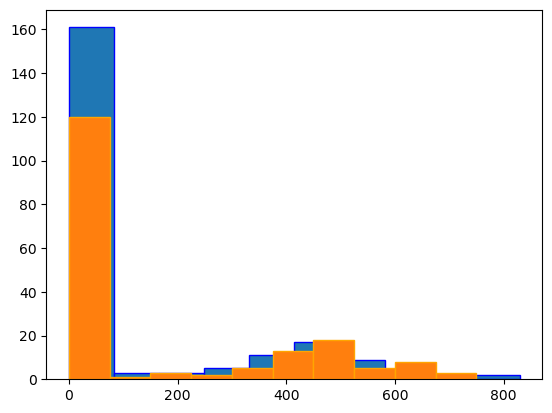

In [16]:
plt.hist(data[data["sex"]=="female"]["working"],edgecolor='blue')
plt.hist(data[data["sex"]=="male"]["working"],edgecolor='orange')

Childcare

(array([6., 2., 4., 1., 1., 2., 0., 1., 1., 2.]),
 array([ 10.,  24.,  38.,  52.,  66.,  80.,  94., 108., 122., 136., 150.]),
 <BarContainer object of 10 artists>)

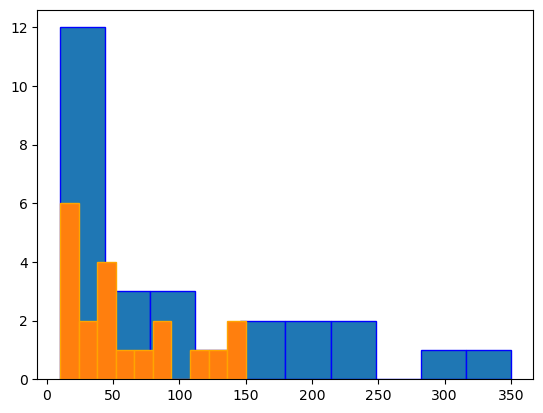

In [18]:
plt.hist(data.loc[(data["sex"] == "female") & (data["childcare"] > 0), "childcare"],edgecolor='blue')
plt.hist(data.loc[(data["sex"] == "male") & (data["childcare"] > 0), "childcare"],edgecolor='orange')

In [19]:
data.groupby("sex")["childcare"].sum()

C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\518613725.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["childcare"].sum()


sex
male      1160
female    2680
Name: childcare, dtype: int64

Sleeping

(array([ 3.,  2.,  1.,  9., 38., 66., 41., 12.,  4.,  2.]),
 array([  0.,  92., 184., 276., 368., 460., 552., 644., 736., 828., 920.]),
 <BarContainer object of 10 artists>)

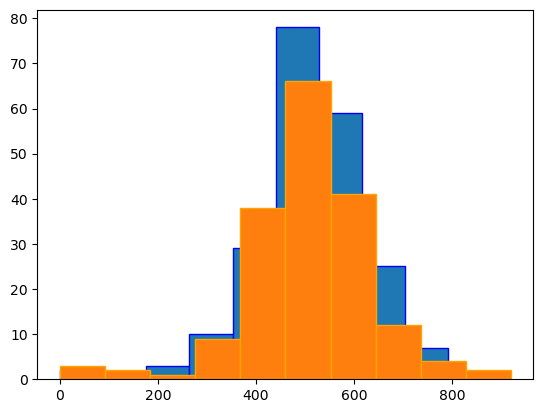

In [21]:
plt.hist(data[data["sex"]=="female"]["sleeping"],edgecolor='blue')
plt.hist(data[data["sex"]=="male"]["sleeping"],edgecolor='orange')

In [22]:
data.groupby("sex")["sleeping"].sum()

C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\3361491928.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["sleeping"].sum()


sex
male       89870
female    108450
Name: sleeping, dtype: int64

Studying

(array([  0.,   0.,   0.,   0.,   0., 178.,   0.,   0.,   0.,   0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

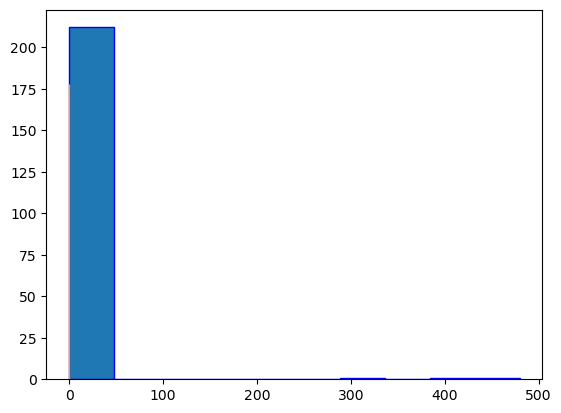

In [24]:
plt.hist(data[data["sex"]=="female"]["studying in school"],edgecolor='blue')
plt.hist(data[data["sex"]=="male"]["studying in school"],edgecolor='orange')

In [25]:
data.groupby("sex")["studying in school"].sum()

C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\2636187199.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["studying in school"].sum()


sex
male         0
female    1200
Name: studying in school, dtype: int64

Cinema

In [27]:
data.groupby("sex")["cinema"].count()

C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\2873114007.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["cinema"].count()


sex
male      164
female    205
Name: cinema, dtype: int64

Sleeping

In [29]:
data.loc[data['cinema'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()

C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\2215824277.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['cinema'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()
C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\2215824277.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['cinema'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()


,kohde,jasen,day of week,age group,living environment,working,childcare,sleeping,studying in school,cinema,library
sex,,,,,,,,,,,
male,0.353933,0.353933,0.353933,0.353933,0.353933,0.353933,0.353933,0.353933,0.353933,0.384146,0.375758
female,0.474419,0.474419,0.474419,0.474419,0.476636,0.474419,0.474419,0.474419,0.474419,0.497561,0.497561


In [30]:
data.loc[data['library'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()

C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\1533313241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['library'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()
C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\1533313241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['library'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()


,kohde,jasen,day of week,age group,living environment,working,childcare,sleeping,studying in school,cinema,library
sex,,,,,,,,,,,
male,0.550562,0.550562,0.550562,0.550562,0.550562,0.550562,0.550562,0.550562,0.550562,0.591463,0.593939
female,0.693023,0.693023,0.693023,0.693023,0.696262,0.693023,0.693023,0.693023,0.693023,0.721951,0.726829



<h1>


With respect to which activities do living environments differ?<h1>

working

(array([42.,  2.,  1.,  2.,  2.,  6.,  5.,  0.,  0.,  1.]),
 array([  0.,  79., 158., 237., 316., 395., 474., 553., 632., 711., 790.]),
 <BarContainer object of 10 artists>)

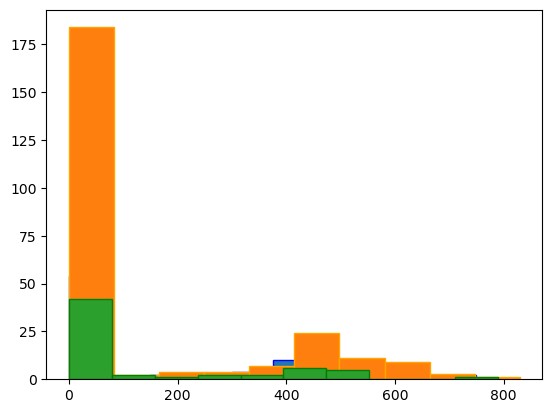

In [33]:
plt.hist(data[data["living environment"]=="rural"]["working"],edgecolor='blue')
plt.hist(data[data["living environment"]=="city"]["working"],edgecolor='orange')
plt.hist(data[data["living environment"]=="munipality"]["working"],edgecolor='green')

childcare

(array([72.,  3.,  2.,  1.,  1.,  1.,  1.,  0.,  0.,  1.]),
 array([  0.,  31.,  62.,  93., 124., 155., 186., 217., 248., 279., 310.]),
 <BarContainer object of 10 artists>)

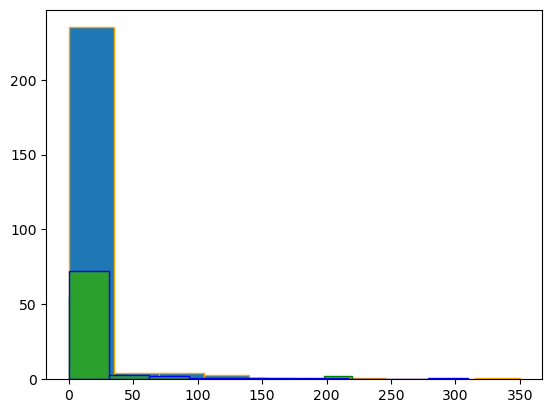

In [35]:

plt.hist(data[data["living environment"]=="city"]["childcare"],edgecolor='orange')
plt.hist(data[data["living environment"]=="munipality"]["childcare"],edgecolor='green')
plt.hist(data[data["living environment"]=="rural"]["childcare"],edgecolor='blue')

sleeping

(array([ 2.,  0.,  1.,  5.,  8., 15., 18., 16., 11.,  6.]),
 array([110., 171., 232., 293., 354., 415., 476., 537., 598., 659., 720.]),
 <BarContainer object of 10 artists>)

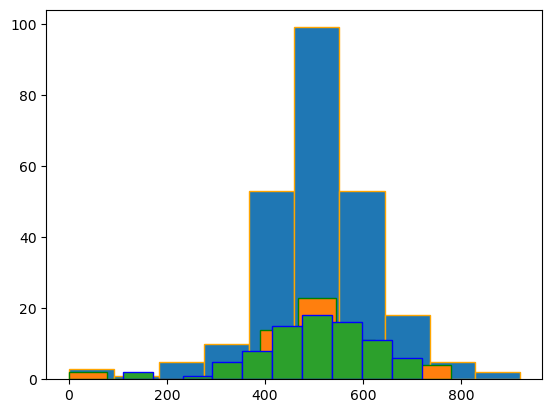

In [37]:

plt.hist(data[data["living environment"]=="city"]["sleeping"],edgecolor='orange')
plt.hist(data[data["living environment"]=="munipality"]["sleeping"],edgecolor='green')
plt.hist(data[data["living environment"]=="rural"]["sleeping"],edgecolor='blue')

studying in school

(array([ 0.,  0.,  0.,  0.,  0., 82.,  0.,  0.,  0.,  0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

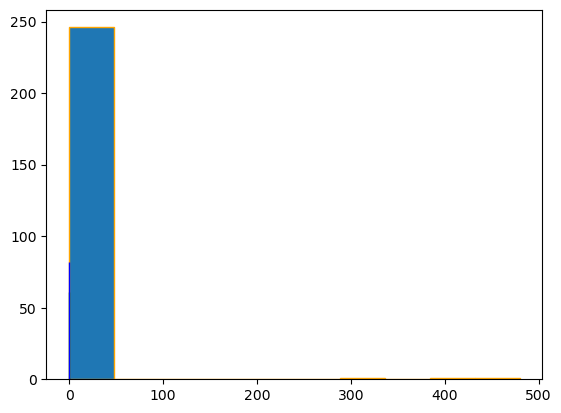

In [39]:

plt.hist(data[data["living environment"]=="city"]["studying in school"],edgecolor='orange')
plt.hist(data[data["living environment"]=="munipality"]["studying in school"],edgecolor='green')
plt.hist(data[data["living environment"]=="rural"]["studying in school"],edgecolor='blue')

library

In [41]:
data.loc[data['library'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()

C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\1211913492.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['library'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()
C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\1211913492.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['library'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()


,kohde,jasen,day of week,sex,age group,working,childcare,sleeping,studying in school,cinema,library
living environment,,,,,,,,,,,
city,0.610442,0.610442,0.610442,0.610442,0.610442,0.610442,0.610442,0.610442,0.610442,0.662281,0.666667
munipality,0.688525,0.688525,0.688525,0.688525,0.688525,0.688525,0.688525,0.688525,0.688525,0.711864,0.711864
rural,0.646341,0.646341,0.646341,0.646341,0.646341,0.646341,0.646341,0.646341,0.646341,0.641975,0.646341


cinema

In [43]:
data.loc[data['cinema'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()

C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\2560204527.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['cinema'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()
C:\Users\Mishqat\AppData\Local\Temp\ipykernel_10608\2560204527.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['cinema'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()


,kohde,jasen,day of week,sex,age group,working,childcare,sleeping,studying in school,cinema,library
living environment,,,,,,,,,,,
city,0.461847,0.461847,0.461847,0.461847,0.461847,0.461847,0.461847,0.461847,0.461847,0.504386,0.500000
munipality,0.442623,0.442623,0.442623,0.442623,0.442623,0.442623,0.442623,0.442623,0.442623,0.457627,0.457627
rural,0.280488,0.280488,0.280488,0.280488,0.280488,0.280488,0.280488,0.280488,0.280488,0.283951,0.280488


<h1>analysis</h1>

# Question 3: Characterizing Individuals

IKAL1     int64
V1       object
V21      object
V32      object
V40      object
H1a_A    object
H1h_A    object
dtype: object
   IKAL1     V1    V21    V32    V40 H1a_A H1h_A
0      6    580      0    430      0   1.0   1.0
1      7      0      0    560      0   1.0   1.0
2      8      0      0    450      0   2.0   1.0
3      8      0      0    530      0   2.0   2.0
4      8  00:00  00:00  07:20  00:00   2.0   2.0
<class 'pandas.core.frame.DataFrame'>
Index: 310 entries, 0 to 391
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IKAL1   310 non-null    int64  
 1   V1      310 non-null    float64
 2   V21     310 non-null    float64
 3   V32     310 non-null    float64
 4   V40     310 non-null    float64
 5   H1a_A   310 non-null    float64
 6   H1h_A   310 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 19.4 KB
None


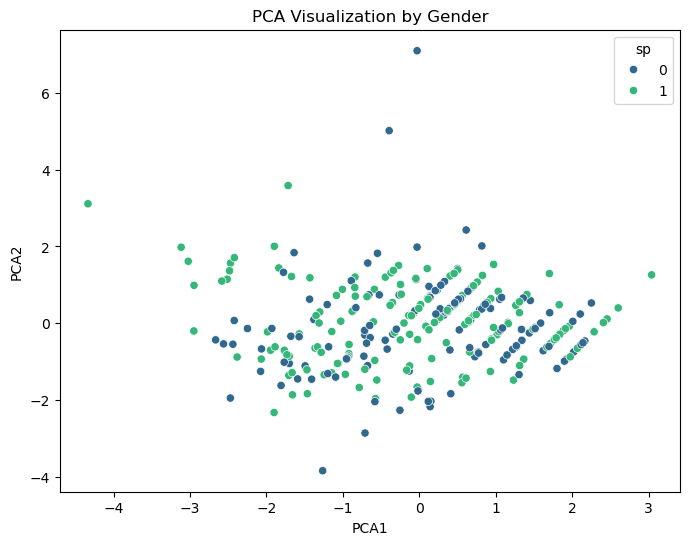

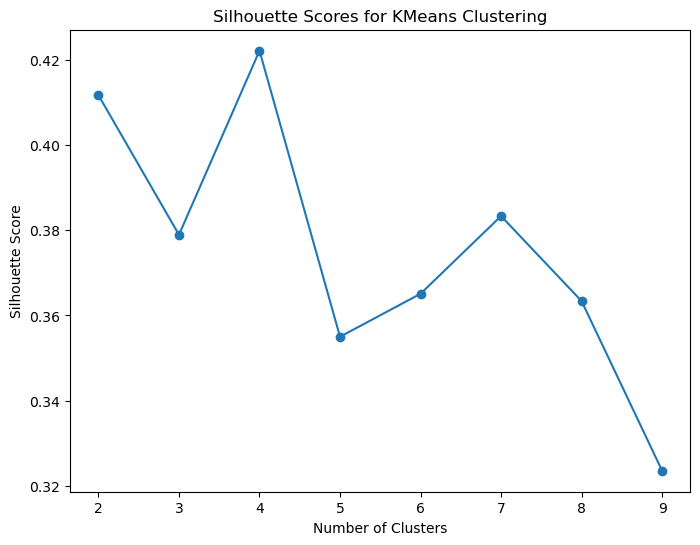

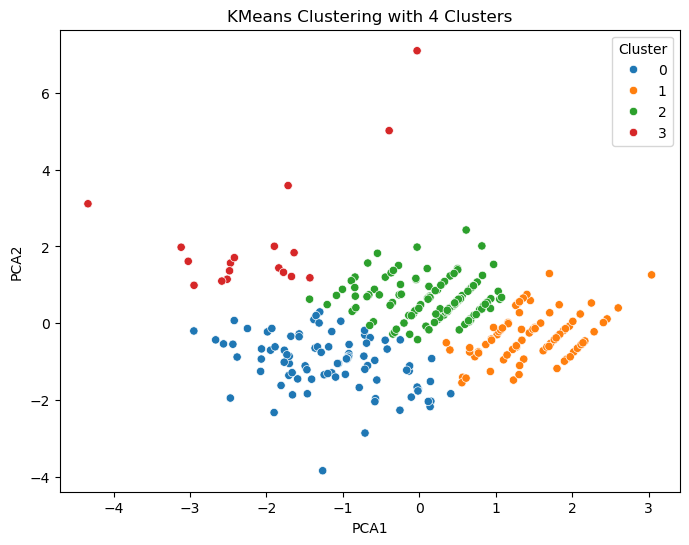

Cluster Characteristics:
                kohde     jasen    pvknro        sp     IKAL1    ASALUE  \
Cluster                                                                   
0        51018.620690  1.344828  1.551724  0.494253 -0.565846  0.712644   
1        50940.234568  1.395062  1.555556  0.530864  0.894092  0.691358   
2        50906.677419  1.451613  1.532258  0.564516 -0.066731  0.524194   
3        50925.444444  1.333333  1.222222  0.777778 -0.828786  0.722222   

               V1       V21       V32       V40     H1a_A     H1h_A      PCA1  \
Cluster                                                                         
0        1.313136  0.021843 -0.765393 -0.097689 -0.110421 -0.191868 -1.155221   
1       -0.463164 -0.276212  0.206339 -0.097689 -0.089615  1.234871  1.481597   
2       -0.559837 -0.195614  0.400527 -0.097689 -0.116822 -0.521641  0.151355   
3       -0.405931  2.484943  0.011688  1.584731  1.741745 -1.036036 -2.126287   

             PCA2  
Cluster          

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load data
file_path = r"C:\Users\Mishqat\Downloads\habits (2).data"  # Adjust path as needed
data = pd.read_csv(file_path, sep=';')  # Assuming tab-separated file

# Select required columns
columns_to_use = ["kohde", "jasen", "pvknro", "sp", "IKAL1", "ASALUE", "V1", "V21", "V32", "V40", "H1a_A", "H1h_A"]
data = data[columns_to_use]

# Data preprocessing
# Handle missing values (drop rows with missing data for simplicity)
data = data.dropna()

# Encode categorical variables (e.g., gender and living area)
data["sp"] = data["sp"].astype('category').cat.codes  # Encode gender
data["ASALUE"] = data["ASALUE"].astype('category').cat.codes  # Encode living area

# Standardize numerical variables
scaler = StandardScaler()
numerical_columns = ["IKAL1", "V1", "V21", "V32", "V40", "H1a_A", "H1h_A"]

print(data[numerical_columns].dtypes)
print(data[numerical_columns].head())
for col in numerical_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data = data.dropna(subset=numerical_columns)
print(data[numerical_columns].info())

data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

# Dimensionality reduction with PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data[numerical_columns])
data["PCA1"] = data_pca[:, 0]
data["PCA2"] = data_pca[:, 1]

# Visualize PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PCA1", y="PCA2", hue="sp", data=data, palette="viridis")
plt.title("PCA Visualization by Gender")
plt.show()

# Clustering using KMeans
# Determine the optimal number of clusters using the silhouette score
range_n_clusters = range(2, 10)
silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(data_pca)
    silhouette_avg = silhouette_score(data_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot silhouette scores
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title("Silhouette Scores for KMeans Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

# Choose optimal number of clusters (e.g., highest silhouette score)
optimal_clusters = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
data["Cluster"] = kmeans.fit_predict(data_pca)

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=data, palette="tab10")
plt.title(f"KMeans Clustering with {optimal_clusters} Clusters")
plt.show()

# Characterize clusters
cluster_characteristics = data.groupby("Cluster").mean()
print("Cluster Characteristics:")
print(cluster_characteristics)

# Question 4: Estimating Average Daily Time on Activities

Average Time Spent on Activities (in minutes):
V1     0.293548
V21    0.187097
V32   -0.003226
V40    0.093548
dtype: float64


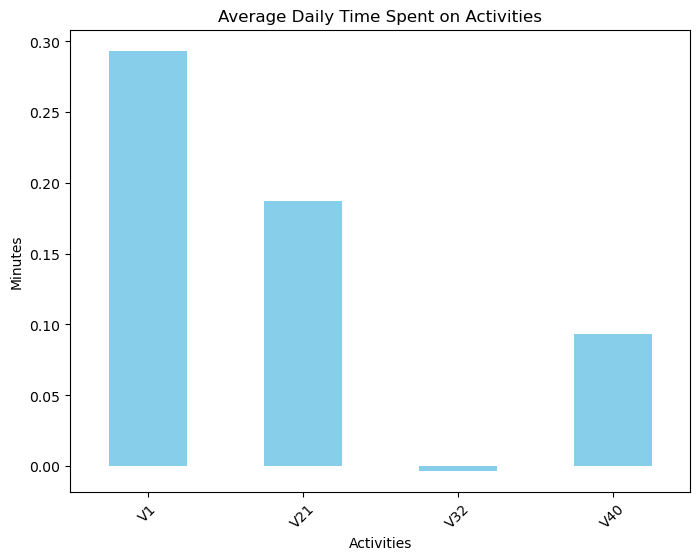

In [57]:
# Function to convert time strings (e.g., "07:20") to minutes
def time_to_minutes(value):
    try:
        if isinstance(value, str) and ":" in value:
            hours, minutes = map(int, value.split(":"))
            return hours * 60 + minutes
        return int(value)
    except ValueError:
        return None

# Clean the time-based variables
time_vars = ["V1", "V21", "V32", "V40"]
for var in time_vars:
    data[var] = data[var].apply(time_to_minutes)

# Calculate mean time for each activity
activity_means = data[time_vars].mean()

# Print results
print("Average Time Spent on Activities (in minutes):")
print(activity_means)

# Visualize average time spent
activity_means.plot(kind='bar', color='skyblue', figsize=(8, 6))
plt.title('Average Daily Time Spent on Activities')
plt.ylabel('Minutes')
plt.xlabel('Activities')
plt.xticks(rotation=45)
plt.show()